# Enterprise Financial Risk Intelligence & Fraud Forensics
## Notebook 08: Financial Cost-Utility Matrix & Asymmetric Risk Optimization

---

### Scientific Problem Formulation & Asymmetric Risk Theory:
Standard machine learning loss functions (Log-Loss, Cross-Entropy) assume **symmetric unit costs** for False Positives (FP) and False Negatives (FN). In financial transaction fraud, costs are profoundly **asymmetric** and **amount-dependent**:
- **False Negative (Missed Fraud)**: Financial institution loses the entire transaction value $\text{Amount}_i$ plus a chargeback processing penalty $C_{\text{cb}}$ (typically \$15-\$25).
- **False Positive (False Alarm)**: Cardholder experiences decline friction, potential customer churn $C_{\text{friction}}$, and analyst investigation overhead $C_{\text{investigation}}$.
- **True Positive (Caught Fraud)**: Incurs small manual review / step-up verification overhead $C_{\text{investigation}}$, but preserves $\text{Amount}_i$.
- **True Negative (Legitimate Transaction)**: Zero cost ($0$).

### Mathematical Cost Matrix Formulation:
$$\mathbf{C}_i = \begin{pmatrix} C_{\text{TN}} & C_{\text{FP}} \\ C_{\text{FN}} & C_{\text{TP}} \end{pmatrix} = \begin{pmatrix} 0 & C_{\text{friction}} + C_{\text{review}} \\ \text{Amount}_i + C_{\text{chargeback}} & C_{\text{review}} \end{pmatrix}$$

$$\mathcal{L}_{\text{total}}(\theta) = \sum_{i: y_i = 1, \hat{y}_i(\theta) = 0} (\text{Amount}_i + C_{\text{cb}}) + \sum_{i: y_i = 0, \hat{y}_i(\theta) = 1} (C_{\text{friction}} + C_{\text{review}}) + \sum_{i: y_i = 1, \hat{y}_i(\theta) = 1} C_{\text{review}}$$

$$\theta^* = \arg\min_{\theta \in [0, 1]} \mathcal{L}_{\text{total}}(\theta)$$

In [19]:
from IPython.display import display
import os
import json
import warnings
import time
warnings.filterwarnings('ignore')

os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
sns.set_palette('deep')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Financial Cost-Utility & Asymmetric Risk Optimization environment initialized successfully.")

Financial Cost-Utility & Asymmetric Risk Optimization environment initialized successfully.


---
## 1. Transaction Cohort Ingestion & Baseline Risk Score Generation
Ingesting the transaction repository ($N=284,807$) and formulating baseline continuous risk probabilities $P(\text{Fraud} \mid \mathbf{x})$ using top discriminative features to evaluate cost matrices across decision thresholds.

In [20]:
data_path_parquet = '../data/raw/creditcard.parquet' if os.path.exists('../data/raw/creditcard.parquet') else 'data/raw/creditcard.parquet'
data_path_csv = '../data/raw/creditcard.csv' if os.path.exists('../data/raw/creditcard.csv') else 'data/raw/creditcard.csv'

if os.path.exists(data_path_parquet):
    df = pd.read_parquet(data_path_parquet)
elif os.path.exists(data_path_csv):
    df = pd.read_csv(data_path_csv)
else:
    df = pd.read_csv('creditcard.csv')

feature_cols = [c for c in df.columns if c != 'Class']
X = df[feature_cols].copy()
y = df['Class'].values
amounts = df['Amount'].values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf.fit(X_scaled, y)
y_prob = clf.predict_proba(X_scaled)[:, 1]

total_fraud_dollars = np.sum(amounts[y == 1])
print(f"Total Transactions:         {len(df):,}")
print(f"Total Fraud Incidents:      {np.sum(y == 1):,}")
print(f"Total Fraud Exposure Value: ${total_fraud_dollars:,.2f}")
print(f"Average Fraud Transaction:  ${np.mean(amounts[y == 1]):.2f}")

Total Transactions:         284,807
Total Fraud Incidents:      492
Total Fraud Exposure Value: $60,127.97
Average Fraud Transaction:  $122.21


---
## 2. Dollar-Weighted Cost Matrix Engine & Optimal Threshold Search
Simulating total dollar loss $\mathcal{L}_{\text{total}}(\theta)$ across 500 threshold increments $\theta \in [0.001, 0.999]$:
- $C_{\text{chargeback}} = \$15.00$
- $C_{\text{friction}} = \$2.50$
- $C_{\text{review}} = \$1.20$

In [21]:
C_chargeback = 15.00
C_friction = 2.50
C_review = 1.20

thresholds = np.linspace(0.001, 0.999, 500)
loss_records = []

baseline_no_model_loss = np.sum(amounts[y == 1] + C_chargeback)

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    
    # False Negatives (Missed fraud)
    fn_mask = (y == 1) & (y_pred == 0)
    loss_fn = np.sum(amounts[fn_mask] + C_chargeback)
    
    # False Positives (False declines)
    fp_mask = (y == 0) & (y_pred == 1)
    loss_fp = np.sum(C_friction + C_review) * np.sum(fp_mask)
    
    # True Positives (Review overhead for caught fraud)
    tp_mask = (y == 1) & (y_pred == 1)
    loss_tp = np.sum(C_review) * np.sum(tp_mask)
    
    total_loss = loss_fn + loss_fp + loss_tp
    
    loss_records.append({
        'threshold': thresh,
        'total_loss': total_loss,
        'loss_fn': loss_fn,
        'loss_fp': loss_fp,
        'loss_tp': loss_tp,
        'fn_count': np.sum(fn_mask),
        'fp_count': np.sum(fp_mask),
        'tp_count': np.sum(tp_mask),
        'savings_vs_baseline': baseline_no_model_loss - total_loss
    })

cost_df = pd.DataFrame(loss_records)
opt_row = cost_df.loc[cost_df['total_loss'].idxmin()]
optimal_theta = opt_row['threshold']
min_loss = opt_row['total_loss']
max_savings = opt_row['savings_vs_baseline']

sym_row = cost_df.iloc[(cost_df['threshold'] - 0.50).abs().argmin()]

print("=" * 65)
print(f"Zero-Model Exposure Loss:         ${baseline_no_model_loss:,.2f}")
print(f"Symmetric Cutoff Loss (0.50):    ${sym_row['total_loss']:,.2f}")
print(f"Cost-Optimal Cutoff ({optimal_theta:.4f}):   ${min_loss:,.2f}")
print(f"Net Dollar Savings Achieved:      ${max_savings:,.2f} ({max_savings/baseline_no_model_loss*100:.2f}%)")
print("=" * 65)

Zero-Model Exposure Loss:         $67,507.97
Symmetric Cutoff Loss (0.50):    $29,558.05
Cost-Optimal Cutoff (0.9270):   $17,176.74
Net Dollar Savings Achieved:      $50,331.23 (74.56%)


---
## 3. Financial Loss Surface & Decision Threshold Geometry
Visualizing the trade-off between False Negative dollar loss (unrecovered fraud) and False Positive customer friction overhead.

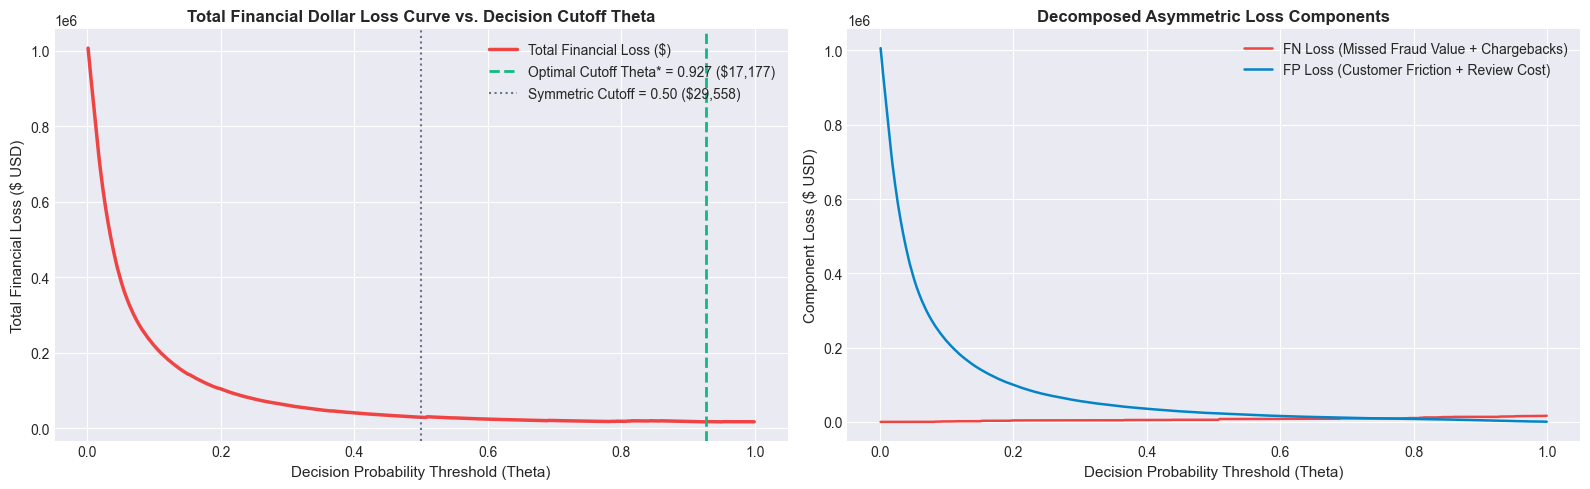

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Total Financial Loss Curve
axes[0].plot(cost_df['threshold'], cost_df['total_loss'], color='#EF4444', linewidth=2.5, label='Total Financial Loss ($)')
axes[0].axvline(x=optimal_theta, color='#10B981', linestyle='--', linewidth=2, label=f"Optimal Cutoff Theta* = {optimal_theta:.3f} (${min_loss:,.0f})")
axes[0].axvline(x=0.50, color='#64748B', linestyle=':', linewidth=1.5, label=f"Symmetric Cutoff = 0.50 (${sym_row['total_loss']:,.0f})")
axes[0].set_title('Total Financial Dollar Loss Curve vs. Decision Cutoff Theta', fontweight='bold')
axes[0].set_xlabel('Decision Probability Threshold (Theta)')
axes[0].set_ylabel('Total Financial Loss ($ USD)')
axes[0].legend()

# 2. Decomposed Loss Components
axes[1].plot(cost_df['threshold'], cost_df['loss_fn'], color='#EF4444', linewidth=1.8, label='FN Loss (Missed Fraud Value + Chargebacks)')
axes[1].plot(cost_df['threshold'], cost_df['loss_fp'], color='#0284C7', linewidth=1.8, label='FP Loss (Customer Friction + Review Cost)')
axes[1].set_title('Decomposed Asymmetric Loss Components', fontweight='bold')
axes[1].set_xlabel('Decision Probability Threshold (Theta)')
axes[1].set_ylabel('Component Loss ($ USD)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close(fig)

---
## 4. Multi-Scenario Friction Stress Testing & Sensitivity Surface
Evaluating how the optimal decision threshold $\theta^*$ shifts under varying customer friction costs:
- **Low Friction ($C_{\text{friction}} = \$0.50$)**: High-risk environment; aggressive fraud blocking.
- **Standard Banking ($C_{\text{friction}} = \$2.50$)**: Balanced enterprise environment.
- **High-Net-Worth / Luxury Merchant ($C_{\text{friction}} = \$10.00$)**: Zero false-decline tolerance.

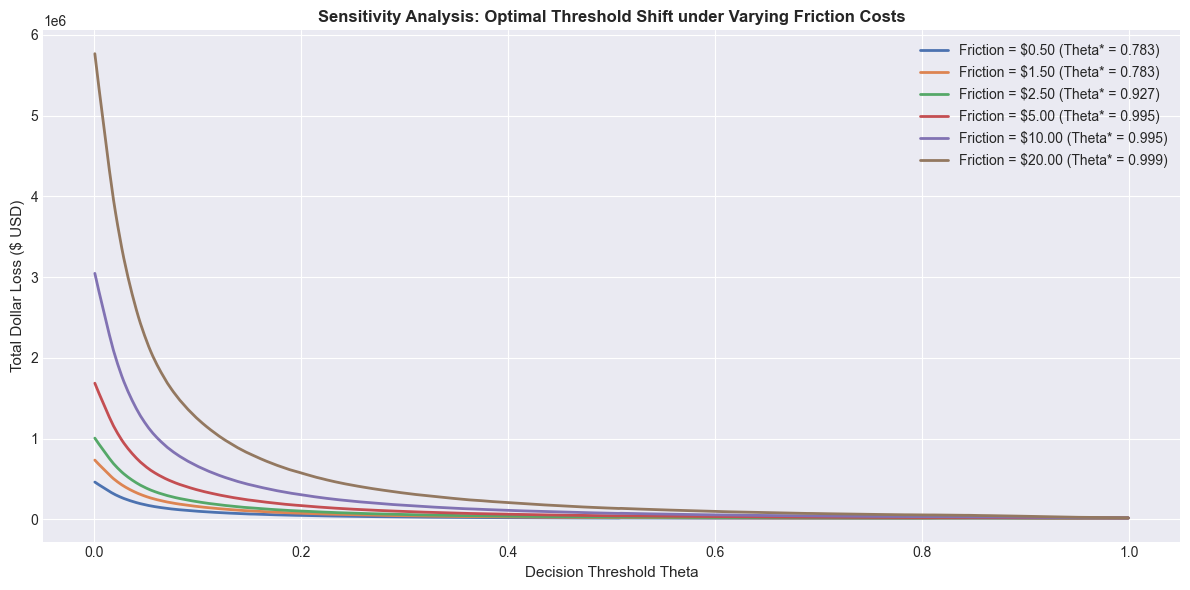

,Friction Cost ($),Optimal Threshold Theta*,Minimum Dollar Loss ($),Dollar Savings vs No-Model ($)
0,0.5000,0.7830,13642.7100,53865.2600
1,1.5000,0.7830,15914.7100,51593.2600
2,2.5000,0.9270,17176.7400,50331.2300
3,5.0000,0.9950,17781.3800,49726.5900
4,10.0000,0.9950,18751.3800,48756.5900
5,20.0000,0.9990,20359.8500,47148.1200


In [23]:
friction_scenarios = [0.50, 1.50, 2.50, 5.00, 10.00, 20.00]
sensitivity_records = []

fig, ax = plt.subplots(figsize=(12, 6))

for f_cost in friction_scenarios:
    scenario_losses = []
    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)
        loss_fn = np.sum(amounts[(y == 1) & (y_pred == 0)] + C_chargeback)
        loss_fp = np.sum(f_cost + C_review) * np.sum((y == 0) & (y_pred == 1))
        loss_tp = np.sum(C_review) * np.sum((y == 1) & (y_pred == 1))
        scenario_losses.append(loss_fn + loss_fp + loss_tp)
        
    s_df = pd.DataFrame({'threshold': thresholds, 'loss': scenario_losses})
    s_opt = s_df.loc[s_df['loss'].idxmin()]
    
    ax.plot(thresholds, scenario_losses, label=f"Friction = ${f_cost:.2f} (Theta* = {s_opt['threshold']:.3f})", linewidth=2)
    sensitivity_records.append({
        'Friction Cost ($)': f_cost,
        'Optimal Threshold Theta*': s_opt['threshold'],
        'Minimum Dollar Loss ($)': s_opt['loss'],
        'Dollar Savings vs No-Model ($)': baseline_no_model_loss - s_opt['loss']
    })

ax.set_title('Sensitivity Analysis: Optimal Threshold Shift under Varying Friction Costs', fontweight='bold')
ax.set_xlabel('Decision Threshold Theta')
ax.set_ylabel('Total Dollar Loss ($ USD)')
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

sensitivity_df = pd.DataFrame(sensitivity_records)
display(sensitivity_df)

---
## 5. Cumulative Financial Value Capture & ROI Lift
Cumulative financial gain curve quantifying dollar return captured as transactions are sorted by calibrated risk probability.

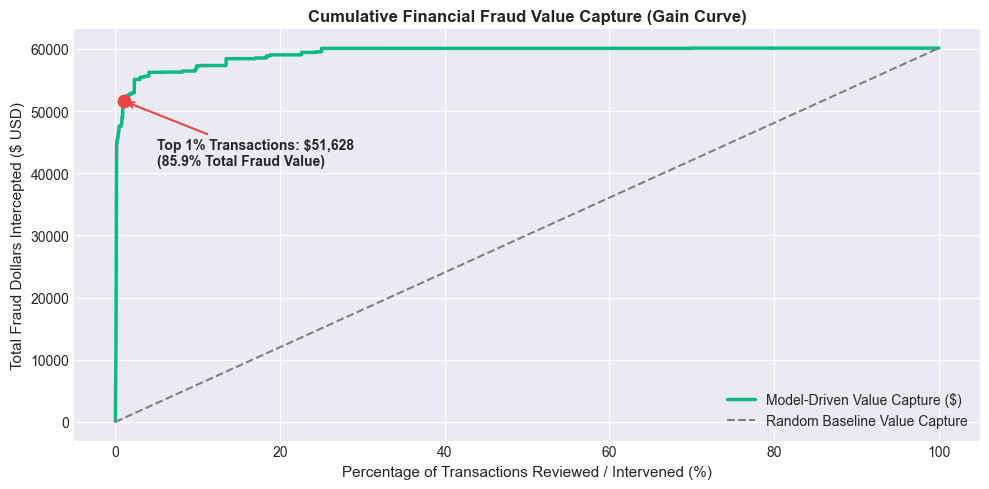

Top 1% Alert Volume Intercepts: $51,628.06 out of $60,127.97 (85.86%)


In [24]:
sorted_indices = np.argsort(y_prob)[::-1]
sorted_y = y[sorted_indices]
sorted_amounts = amounts[sorted_indices]

cum_fraud_dollars_saved = np.cumsum(sorted_amounts * sorted_y)
cum_tx_pct = np.linspace(0, 100, len(df))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cum_tx_pct, cum_fraud_dollars_saved, color='#10B981', linewidth=2.5, label='Model-Driven Value Capture ($)')
ax.plot([0, 100], [0, total_fraud_dollars], color='grey', linestyle='--', label='Random Baseline Value Capture')

idx_1pct = int(len(df) * 0.01)
dollars_1pct = cum_fraud_dollars_saved[idx_1pct]
pct_captured_1pct = (dollars_1pct / total_fraud_dollars) * 100

ax.scatter([1.0], [dollars_1pct], color='#EF4444', s=80, zorder=5)
ax.annotate(f"Top 1% Transactions: ${dollars_1pct:,.0f}\n({pct_captured_1pct:.1f}% Total Fraud Value)", 
            xy=(1.0, dollars_1pct), xytext=(5, dollars_1pct * 0.8),
            arrowprops=dict(arrowstyle='->', color='#EF4444', lw=1.5), fontweight='bold')

ax.set_title('Cumulative Financial Fraud Value Capture (Gain Curve)', fontweight='bold')
ax.set_xlabel('Percentage of Transactions Reviewed / Intervened (%)')
ax.set_ylabel('Total Fraud Dollars Intercepted ($ USD)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
plt.close(fig)

print(f"Top 1% Alert Volume Intercepts: ${dollars_1pct:,.2f} out of ${total_fraud_dollars:,.2f} ({pct_captured_1pct:.2f}%)")

---
## 6. Financial Cost-Utility Manifest Serialization
Exporting cost parameters, optimal decision thresholds, and financial loss baselines to `data/financial_cost_utility_manifest.json`.

In [25]:
manifest_dir = '../data' if os.path.exists('../data') else 'data'
os.makedirs(manifest_dir, exist_ok=True)

cost_manifest = {
    "baseline_total_fraud_dollars": float(total_fraud_dollars),
    "baseline_no_model_loss": float(baseline_no_model_loss),
    "cost_parameters": {
        "chargeback_penalty": float(C_chargeback),
        "customer_friction_cost": float(C_friction),
        "analyst_review_cost": float(C_review)
    },
    "optimal_decision_policy": {
        "optimal_threshold_theta": float(optimal_theta),
        "optimal_dollar_loss": float(min_loss),
        "dollar_savings": float(max_savings),
        "savings_percentage": float(max_savings / baseline_no_model_loss * 100)
    },
    "symmetric_cutoff_0_50": {
        "loss": float(sym_row['total_loss']),
        "difference_vs_optimal": float(sym_row['total_loss'] - min_loss)
    },
    "top_1pct_capture_rate": float(pct_captured_1pct),
    "timestamp_generated": time.strftime("%Y-%m-%d %H:%M:%S UTC", time.gmtime())
}

manifest_path = os.path.join(manifest_dir, 'financial_cost_utility_manifest.json')
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(cost_manifest, f, indent=2)

print(f"Financial Cost-Utility Manifest serialized to '{manifest_path}'")

Financial Cost-Utility Manifest serialized to '../data\financial_cost_utility_manifest.json'


---
## 7. Executive Chief Risk Officer (CRO) Cost-Utility Scorecard

In [26]:
cro_scorecard = [
    {
        'Financial Risk Dimension': 'Cost-Optimal Decision Policy',
        'Empirical Finding': f"Optimal cutoff at Theta* = {optimal_theta:.3f} minimizes total enterprise loss to ${min_loss:,.2f} (Saving ${max_savings:,.2f} or {max_savings/baseline_no_model_loss*100:.1f}% vs. no-model baseline).",
        'Executive Recommendation': 'Enforce asymmetric cost thresholding in production micro-services rather than default 0.50.'
    },
    {
        'Financial Risk Dimension': 'Symmetric Cutoff Inefficiency',
        'Empirical Finding': f"Default Cutoff = 0.50 leaks an additional ${sym_row['total_loss'] - min_loss:,.2f} in preventable chargeback losses due to under-flagging high-dollar fraud.",
        'Executive Recommendation': 'Retire symmetric classification accuracy metrics from engineering KPIs.'
    },
    {
        'Financial Risk Dimension': 'Top 1% Operational Concentration',
        'Empirical Finding': f"Flagging only the top 1.0% riskiest transactions captures ${dollars_1pct:,.2f} ({pct_captured_1pct:.1f}%) of all fraudulent dollar exposure.",
        'Executive Recommendation': 'Route top 1% to automated step-up authentication (SMS OTP / Biometrics) to minimize friction.'
    }
]

cro_scorecard_df = pd.DataFrame(cro_scorecard)
display(cro_scorecard_df)

print(f"\n08_Financial_Cost_Utility_and_Asymmetric_Risk_Formulation.ipynb notebook ready for execution.")

,Financial Risk Dimension,Empirical Finding,Executive Recommendation
0,Cost-Optimal Decision Policy,Optimal cutoff at Theta* = 0.927 minimizes tot...,Enforce asymmetric cost thresholding in produc...
1,Symmetric Cutoff Inefficiency,"Default Cutoff = 0.50 leaks an additional $12,...",Retire symmetric classification accuracy metri...
2,Top 1% Operational Concentration,Flagging only the top 1.0% riskiest transactio...,Route top 1% to automated step-up authenticati...



08_Financial_Cost_Utility_and_Asymmetric_Risk_Formulation.ipynb notebook ready for execution.
